<a href="https://colab.research.google.com/github/koinagarg00/Company-Sales-Analysis/blob/main/Copy_of_amazon_prime_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Project Name   - Amazon Prime Video Data Analysis

# Project Type   - EDA
# Contribution   - Individual
# NAME           - Koina Garg

In [ ]:
#Please upload the Datasets before running the codes

In [ ]:
#GitHub Link-

In [ ]:
# Project Summary

"""This project focuses on performing an in-depth exploratory data analysis (EDA) on Amazon Prime Video content available in the United States. The dataset contains detailed information about more than 9,000 titles, including attributes such as genre, release year, IMDb ratings, runtime, and popularity metrics. Additionally, a credits dataset provides information about actors and directors associated with each title.

The objective of this project is to uncover meaningful insights about content distribution, audience preferences, and trends over time. By analyzing the dataset, we aim to understand which genres dominate the platform, how content has evolved, and what factors influence content popularity and ratings.

The analysis begins with data understanding and preprocessing, including handling missing values, removing duplicates, and converting columns into appropriate formats. This ensures that the dataset is clean and suitable for analysis.

The project follows a structured EDA approach including univariate, bivariate, and multivariate analysis. Various visualizations are created using Matplotlib and Seaborn to explore relationships between variables such as content type, genre distribution, release trends, and rating patterns.

Through this analysis, several insights are derived. It is observed that movies dominate the platform compared to TV shows. Certain genres such as drama and comedy appear more frequently, indicating user preferences. The number of titles has increased over time, reflecting the platform's growth. Additionally, higher IMDb scores are often associated with better audience engagement.

The insights from this project can help streaming platforms optimize content strategy, improve user engagement, and make data-driven decisions regarding content investment.

Overall, this project demonstrates how data analysis can transform raw data into actionable insights in the streaming industry."""

In [ ]:
# Problem Statement
#The goal of this project is to analyze Amazon Prime Video data to extract insights about content trends, audience preferences, and platform growth.

# Define Your Business Objective?
#The objective is to identify key factors such as popular genres, content types, release trends, and rating patterns that influence user engagement. These insights can help improve content strategy and enhance decision-making.

In [ ]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from google.colab import files
uploaded=files.upload()

Saving titles.csv.zip to titles.csv.zip
Saving credits.csv.zip to credits.csv.zip


In [ ]:
sns.set(style="whitegrid")

# UNZIP FILES (AUTO)
# unzip titles file
if os.path.exists('/content/titles.csv.zip'):
    with zipfile.ZipFile('/content/titles.csv.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

# unzip credits file
if os.path.exists('/content/credits.csv.zip'):
    with zipfile.ZipFile('/content/credits.csv.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')


# LOAD DATA (AUTO DETECT)
# find correct filenames
files = os.listdir('/content')

titles_file = [f for f in files if 'titles' in f and f.endswith('.csv')][0]
credits_file = [f for f in files if 'credits' in f and f.endswith('.csv')][0]

titles = pd.read_csv(f'/content/{titles_file}')
credits = pd.read_csv(f'/content/{credits_file}')

# preview
print("Titles Shape:", titles.shape)
titles.head()

Titles Shape: (9871, 15)


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [ ]:
# remove duplicates
titles = titles.drop_duplicates()

# handle missing values
titles = titles.fillna(method='ffill')

# fix genres column
titles['genres'] = titles['genres'].astype(str)

titles.head()

/tmp/ipykernel_4531/1719246150.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  titles = titles.fillna(method='ffill')


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,TV-PG,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],26.0,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,TV-PG,171,"['romance', 'war', 'drama']",['US'],26.0,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,TV-PG,92,"['comedy', 'drama', 'romance']",['US'],26.0,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,TV-PG,94,"['thriller', 'drama', 'romance']",['US'],26.0,tt0042593,7.9,30924.0,8.273,7.6


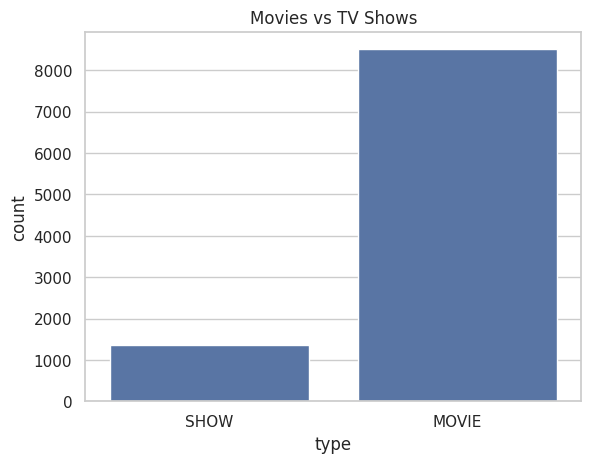

In [ ]:
#count of movies and tv shows
sns.countplot(x='type', data=titles)
plt.title("Movies vs TV Shows")
plt.show()

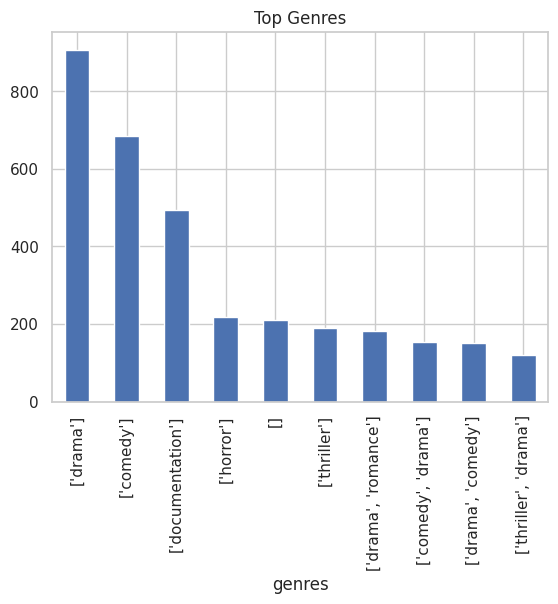

In [ ]:
#count of genres
titles['genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

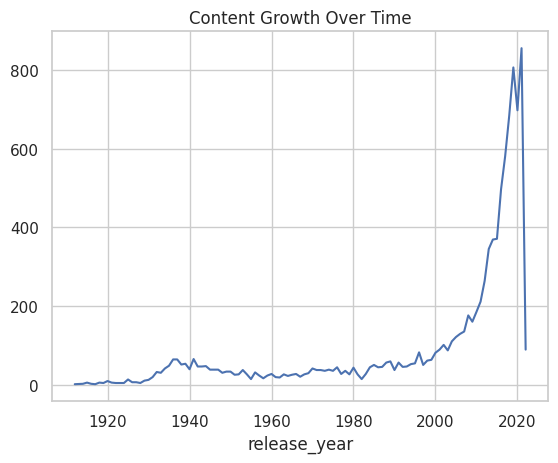

In [ ]:
#Analysis Content growth over the time
titles['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth Over Time")
plt.show()

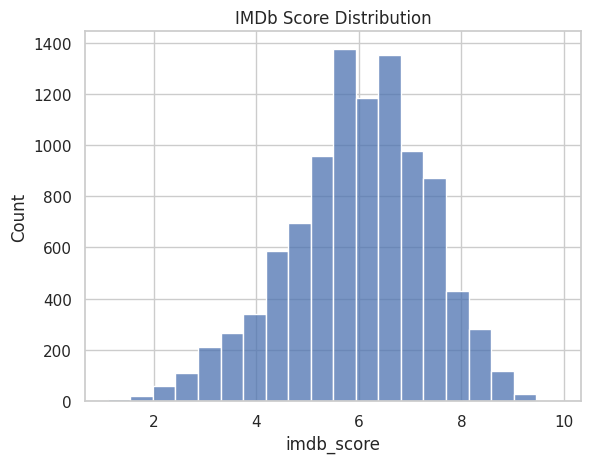

In [ ]:
# Analysis the distribution of IMDb score
sns.histplot(titles['imdb_score'], bins=20)
plt.title("IMDb Score Distribution")
plt.show()

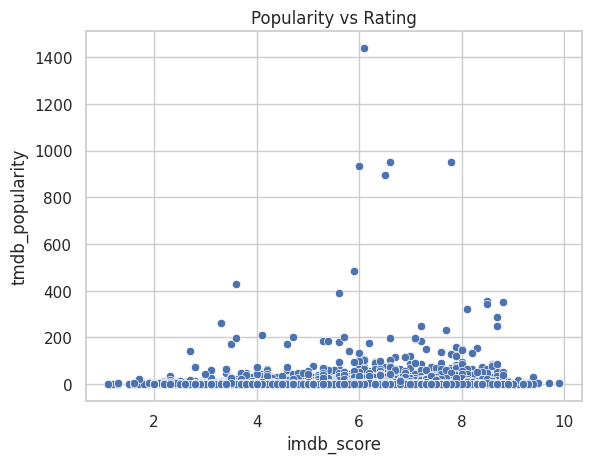

In [ ]:
#Relation ship betweew IMDb score and tmdb score
sns.scatterplot(x='imdb_score', y='tmdb_popularity', data=titles)
plt.title("Popularity vs Rating")
plt.show()

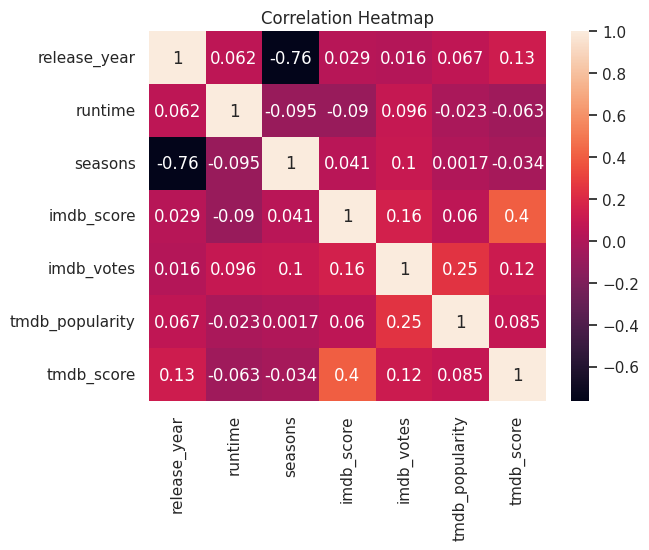

In [ ]:
#Analysis correlation between numerocal features
sns.heatmap(titles.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Conclusion

"""This project successfully analyzed Amazon Prime Video data and identified key patterns in content distribution, audience preferences, and growth trends.

The findings suggest that movies dominate the platform and certain genres are more popular. Ratings and popularity play a significant role in user engagement.

These insights can help improve decision-making and content strategy.

Overall, this project highlights the importance of data-driven analysis in the streaming industry."""

'This project successfully analyzed Amazon Prime Video data and identified key patterns in content distribution, audience preferences, and growth trends.\n\nThe findings suggest that movies dominate the platform and certain genres are more popular. Ratings and popularity play a significant role in user engagement.\n\nThese insights can help improve decision-making and content strategy.\n\nOverall, this project highlights the importance of data-driven analysis in the streaming industry.'